Heart Disease Prediction & Explainability
Mira AL-salhi **bold text** **bold text**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV



Data Loading & Exploration

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('heart.csv')
print(df.head())


   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
df.info()
df.describe()
missing_values = df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


 Preprocessing


In [ ]:
df_c= df.copy()

In [ ]:
# Replace zero valuefor'RestingBP' and 'Cholesterol' with mediann
for col in ['RestingBP', 'Cholesterol']:
    non_zero_median = df_c[df_c[col] > 0][col].median()
    df_c[col] = df_c[col].replace(0, non_zero_median)

# Encode categorical variables
label_encoders = {}
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_cols:
    le = LabelEncoder()
    df_c[col] = le.fit_transform(df_c[col])
    label_encoders[col] = le

Train/Test Split

In [ ]:
X = df_c.drop('HeartDisease', axis=1)
y = df_c['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Models

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}


In [ ]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })


In [ ]:
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.842391   0.906250  0.813084  0.857143
1        Decision Tree  0.815217   0.919540  0.747664  0.824742
2        Random Forest  0.869565   0.902913  0.869159  0.885714


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

train_results = []
for name, model in models.items():
    # Predict on the training data
    y_train_pred = model.predict(X_train)

    # Compute metrics
    train_results.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Train Precision': precision_score(y_train, y_train_pred),
        'Train Recall': recall_score(y_train, y_train_pred),
        'Train F1 Score': f1_score(y_train, y_train_pred)
    })

train_results_df = pd.DataFrame(train_results)
print(train_results_df)

                 Model  Train Accuracy  Train Precision  Train Recall  \
0  Logistic Regression        0.847411          0.85679      0.865337   
1        Decision Tree        1.000000          1.00000      1.000000   
2        Random Forest        1.000000          1.00000      1.000000   

   Train F1 Score  
0        0.861042  
1        1.000000  
2        1.000000  


Hyperparameter Tuning

In [ ]:

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           scoring='f1', cv=3, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy: 0.8804347826086957
Precision: 0.912621359223301
Recall: 0.8785046728971962
F1 Score: 0.8952380952380953


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


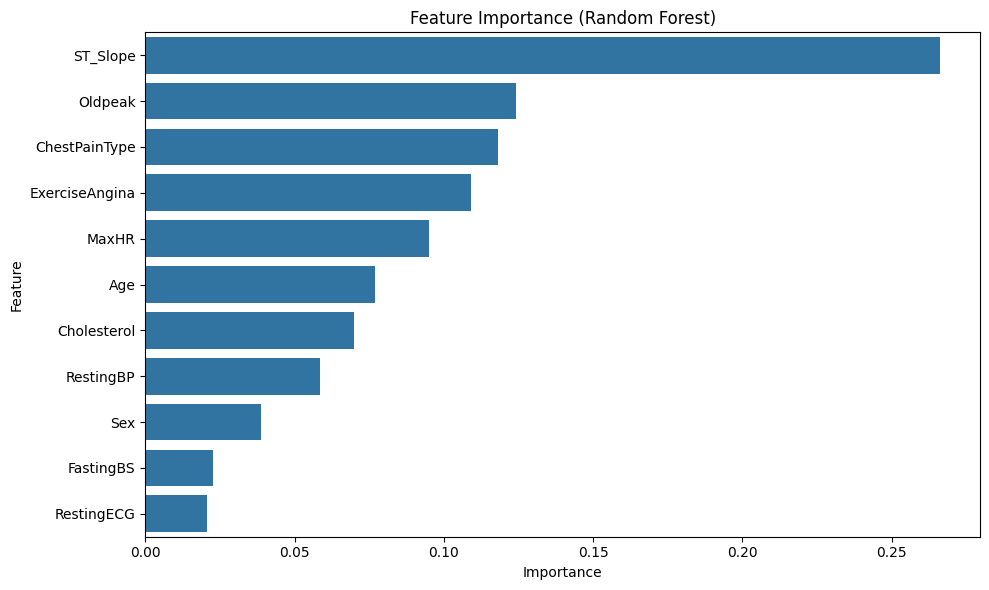

,Feature,Importance
10,ST_Slope,0.266324
9,Oldpeak,0.124257
2,ChestPainType,0.118106
8,ExerciseAngina,0.109022
7,MaxHR,0.095113
0,Age,0.076887
4,Cholesterol,0.069768
3,RestingBP,0.058559
1,Sex,0.038606
5,FastingBS,0.022572


In [ ]:
importances = best_rf.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

feature_importance_df

In [ ]:
X_reduced = X.drop(columns=['RestingECG', 'FastingBS', 'Sex'])
#now i re splitn to retrain the besttttttt preformannceeee for rf
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

best_rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
best_rf.fit(X_train_r, y_train_r)
y_pred_r = best_rf.predict(X_test_r)
#evaluationn
print("Reduced Model Performance:")
print("Accuracy:", accuracy_score(y_test_r, y_pred_r))
print("Precision:", precision_score(y_test_r, y_pred_r))
print("Recall:", recall_score(y_test_r, y_pred_r))
print("F1 Score:", f1_score(y_test_r, y_pred_r))

Reduced Model Performance:
Accuracy: 0.8586956521739131
Precision: 0.9090909090909091
Recall: 0.8411214953271028
F1 Score: 0.8737864077669902


 Results & Explainability Visualization

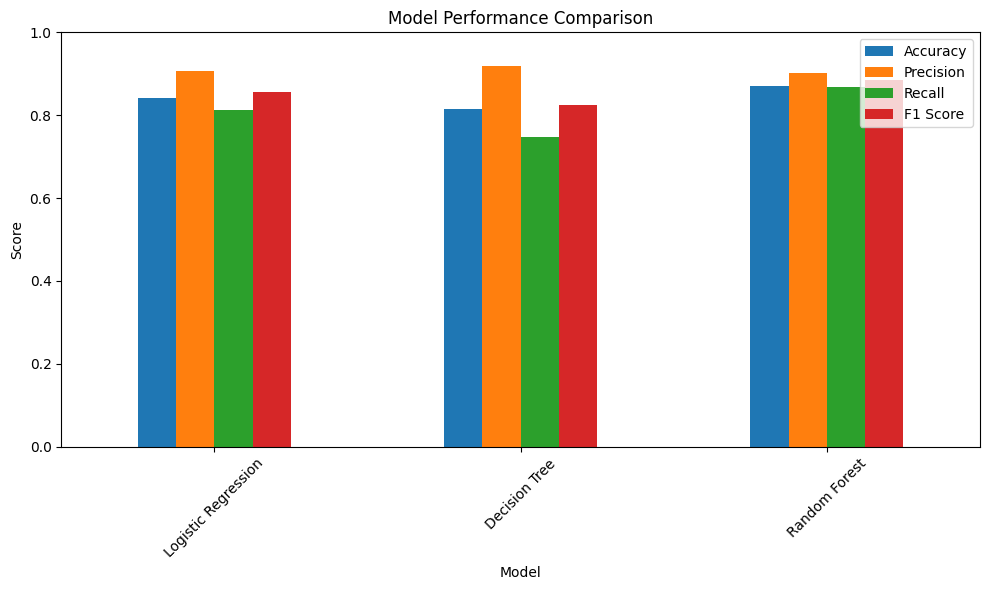

In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import shap
#this is bar chart to model peefomance
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
ax = results_df.set_index('Model')[metrics].plot(kind='bar', figsize=(10,6))
ax.set_ylim(0,1)
ax.set_title('Model Performance Comparison')
ax.set_ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:


import numpy as np
import shap
explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)
print("Type of shap_values:", type(shap_values))
if isinstance(shap_values, list):
    print("Number of classes (list length):", len(shap_values))
    print("Shape of shap_values[0]:", np.array(shap_values[0]).shape)
    print("Shape of shap_values[1]:", np.array(shap_values[1]).shape)
else:
    print("shap_values array shape:", shap_values.shape)

print("X_test shape:", X_test.shape)
print("X_test columns count:", X_test.shape[1])


Type of shap_values: <class 'numpy.ndarray'>
shap_values array shape: (184, 11, 2)
X_test shape: (184, 11)
X_test columns count: 11


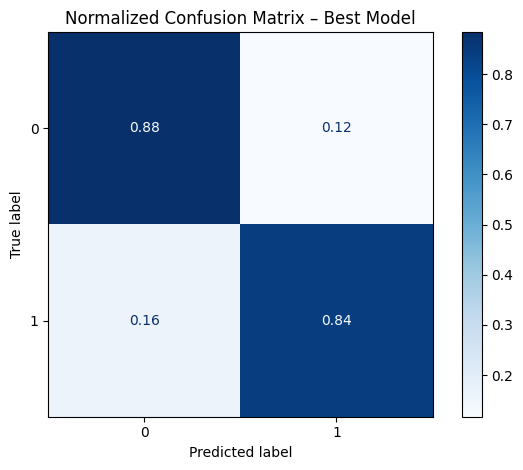

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

feature_order = best_rf.feature_names_in_
X_test_aligned = X_test[feature_order]

disp = ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test_aligned,
    y_test,
    cmap='Blues',
    normalize='true'
)
disp.ax_.set_title('Normalized Confusion Matrix – Best Model')
plt.tight_layout()
plt.show()

In [ ]:
class1_shap = shap_values[:, :, 1]
print("Class 1 SHAP shape:", class1_shap.shape)

Class 1 SHAP shape: (184, 11)


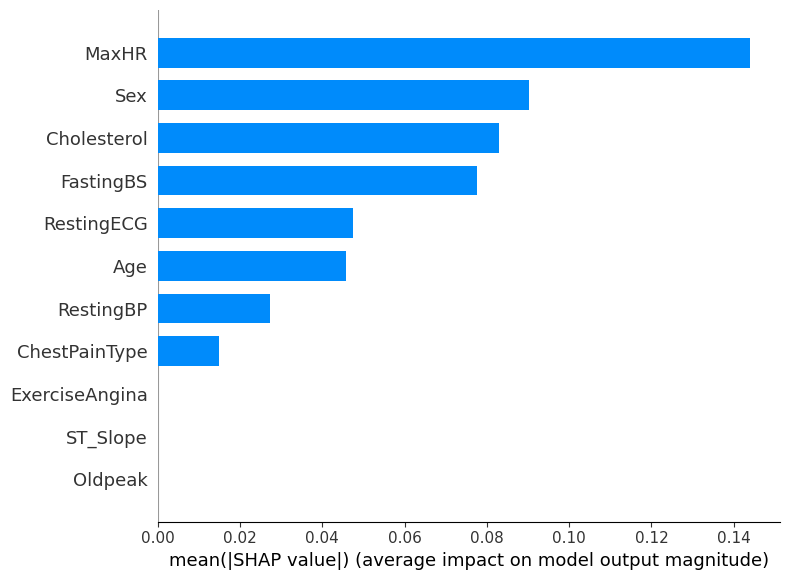

In [ ]:
shap.summary_plot(
    class1_shap,
    X_test,
    plot_type='bar'
)